# Solar Cycle Peak Forecasting — Phase 5: Trajectory Forecasting

**Goal:** Predict the full monthly sunspot trajectory from early-cycle observations, then extract peak magnitude and timing.

**Input:** First 36 observed months (matching Phase 3/4 best window)  
**Output:** Full cycle trajectory → `peak_value = max(trajectory)`, `peak_month = argmax(trajectory)`  
**Models:** GRU · LSTM · TCN  
**Validation:** Leave-One-Cycle-Out (LOCO) — same protocol as Phase 3/4  
**Baseline:** Phase 3/4 RandomForest results for direct comparison

In [1]:
import subprocess, sys
try:
    import torch
    print(f"PyTorch {torch.__version__} already installed")
except ImportError:
    print("Installing PyTorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--quiet"])
    import torch
    print(f"PyTorch {torch.__version__} installed")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time, os
warnings.filterwarnings("ignore")

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Imports OK")

PyTorch 2.12.0+cpu already installed
Imports OK


In [2]:
WINDOW      = 36       # observation window in months — matches Phase 3/4 best window
NORM_FACTOR = 300.0    # fixed physical bound — no leakage
N_EPOCHS    = 200      # max training epochs per fold
PATIENCE    = 25       # early-stopping patience
LR          = 1e-3
HIDDEN      = 64       # GRU/LSTM hidden size
DROPOUT     = 0.2

print(f"Config: window={WINDOW}m | norm={NORM_FACTOR} | epochs={N_EPOCHS} | hidden={HIDDEN}")

Config: window=36m | norm=300.0 | epochs=200 | hidden=64


## Load Data

In [3]:
monthly = pd.read_csv("../data/SN_monthly_clean.csv", parse_dates=["Date"])
monthly = monthly.sort_values("Date").reset_index(drop=True)

comp = pd.read_csv("../data/Cycle_Database_completed.csv",
                   parse_dates=["Start_Date","End_Date","Peak_Date"])
comp = comp.sort_values("Cycle_ID").reset_index(drop=True)

print(f"Monthly records : {len(monthly)}")
print(f"Completed cycles: {len(comp)}  (SC1 - SC{int(comp['Cycle_ID'].max())})")
comp[["Cycle_ID","Start_Date","End_Date","Peak_Sunspot_Number","Rise_Time_months"]].head(6)

Monthly records : 3329
Completed cycles: 24  (SC1 - SC24)


,Cycle_ID,Start_Date,End_Date,Peak_Sunspot_Number,Rise_Time_months
0,1,1755-02-01,1766-06-01,144.1,76.0
1,2,1766-06-01,1775-06-01,193.0,39.0
2,3,1775-06-01,1784-09-01,264.2,35.0
3,4,1784-09-01,1798-04-01,235.3,41.0
4,5,1798-04-01,1810-07-01,82.0,82.0
5,6,1810-07-01,1823-05-01,81.2,70.0


## Extract Cycle Trajectories

In [4]:
trajectories = {}
for _, cycle in comp.iterrows():
    cid   = int(cycle["Cycle_ID"])
    start = cycle["Start_Date"]
    end   = cycle["End_Date"]
    mask  = (monthly["Date"] >= start) & (monthly["Date"] <= end)
    sn    = monthly.loc[mask, "SN_clean"].values.copy()
    sn    = np.where(np.isnan(sn), 0.0, sn)
    trajectories[cid] = sn

cycle_ids = sorted(trajectories.keys())
lengths   = [len(trajectories[c]) for c in cycle_ids]
MAX_LEN   = max(lengths)

print(f"Cycle lengths: min={min(lengths)}  max={max(lengths)}  mean={np.mean(lengths):.1f}")
print(f"MAX_LEN = {MAX_LEN}")
print(f"All cycles have >= {WINDOW} months: {all(l >= WINDOW for l in lengths)}")

# Padded trajectories and binary masks
padded_trajs = {}
traj_masks   = {}
for cid in cycle_ids:
    traj = trajectories[cid]
    p    = np.zeros(MAX_LEN)
    p[:len(traj)] = traj
    padded_trajs[cid] = p
    m    = np.zeros(MAX_LEN)
    m[:len(traj)] = 1.0
    traj_masks[cid] = m

print("Trajectories extracted and padded.")

Cycle lengths: min=109  max=164  mean=133.4
MAX_LEN = 164
All cycles have >= 36 months: True
Trajectories extracted and padded.


## Model Definitions

All models share the same interface:
- **Input:** `(batch, WINDOW, 1)` — normalised monthly SN for first `WINDOW` months  
- **Output:** `(batch, MAX_LEN)` — full predicted cycle trajectory (normalised, non-negative)

In [5]:
class GRUForecaster(nn.Module):
    def __init__(self, output_size, hidden_size=HIDDEN, num_layers=2, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_size),
            nn.ReLU(),
        )
    def forward(self, x):
        _, h = self.gru(x)
        return self.head(h[-1])


class LSTMForecaster(nn.Module):
    def __init__(self, output_size, hidden_size=HIDDEN, num_layers=2, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_size),
            nn.ReLU(),
        )
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])


class TCNForecaster(nn.Module):
    """Dilated-conv encoder → global pool → dense trajectory output."""
    def __init__(self, output_size, dropout=DROPOUT):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(32, 64, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(64, 64, kernel_size=3, padding=4, dilation=4),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_size),
            nn.ReLU(),
        )
    def forward(self, x):
        x   = x.permute(0, 2, 1)       # (batch, 1, seq_len)
        out = self.encoder(x)
        out = self.pool(out).squeeze(-1)
        return self.head(out)


# Sanity check — shapes
dummy = torch.zeros(4, WINDOW, 1)
for cls in [GRUForecaster, LSTMForecaster, TCNForecaster]:
    m   = cls(output_size=MAX_LEN)
    out = m(dummy)
    print(f"  {cls.__name__:<18s}: {tuple(dummy.shape)} -> {tuple(out.shape)}")
print("Model definitions OK")

  GRUForecaster     : (4, 36, 1) -> (4, 164)
  LSTMForecaster    : (4, 36, 1) -> (4, 164)
  TCNForecaster     : (4, 36, 1) -> (4, 164)
Model definitions OK


## Training Utilities

In [9]:
def masked_mse(pred, target, mask):
    """MSE computed only on non-padded positions."""
    return ((pred - target) ** 2 * mask).sum() / (mask.sum() + 1e-8)


def train_model(model_class, X_train, Y_train, M_train, output_size):
    """
    Train a trajectory forecaster with early stopping.
    X_train : (N, WINDOW)   — normalised observed months
    Y_train : (N, MAX_LEN)  — normalised full trajectories
    M_train : (N, MAX_LEN)  — binary masks (1 = real data, 0 = padding)
    """
    model = model_class(output_size=output_size)
    opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    Xt = torch.FloatTensor(X_train).unsqueeze(-1)   # (N, W, 1)
    Yt = torch.FloatTensor(Y_train)
    Mt = torch.FloatTensor(M_train)

    best_loss, best_state, wait = float("inf"), None, 0
    model.train()
    for epoch in range(N_EPOCHS):
        opt.zero_grad()
        loss = masked_mse(model(Xt), Yt, Mt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step(loss.item())
        if loss.item() < best_loss - 1e-6:
            best_loss  = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model

print("Training utilities ready.")

Training utilities ready.


## LOCO CV — Trajectory Prediction

In [10]:
def loco_cv_trajectory(model_class, window=WINDOW):
    """
    Leave-One-Cycle-Out CV for trajectory models.
    Returns per-cycle peak magnitude and timing predictions.
    """
    records = []
    for test_cid in cycle_ids:
        train_cids = [c for c in cycle_ids if c != test_cid]

        X_tr = np.array([trajectories[c][:window] / NORM_FACTOR for c in train_cids])
        Y_tr = np.array([padded_trajs[c]          / NORM_FACTOR for c in train_cids])
        M_tr = np.array([traj_masks[c]                           for c in train_cids])

        # Observed window for test cycle (handle rare short cycles)
        obs       = np.zeros(window)
        tlen      = min(len(trajectories[test_cid]), window)
        obs[:tlen] = trajectories[test_cid][:tlen] / NORM_FACTOR

        model    = train_model(model_class, X_tr, Y_tr, M_tr, output_size=MAX_LEN)
        with torch.no_grad():
            pred_norm = model(torch.FloatTensor(obs).unsqueeze(0).unsqueeze(-1)).numpy()[0]

        pred_traj   = pred_norm * NORM_FACTOR
        actual_traj = trajectories[test_cid]
        actual_len  = len(actual_traj)

        pred_peak_mag   = float(pred_traj[:actual_len].max())
        pred_peak_month = int(pred_traj[:actual_len].argmax()) + 1
        actual_peak_mag   = float(actual_traj.max())
        actual_peak_month = int(actual_traj.argmax()) + 1

        records.append({
            "Cycle_ID":          test_cid,
            "actual_peak_mag":   actual_peak_mag,
            "pred_peak_mag":     pred_peak_mag,
            "mag_error":         pred_peak_mag - actual_peak_mag,
            "mag_abs_error":     abs(pred_peak_mag - actual_peak_mag),
            "actual_peak_month": actual_peak_month,
            "pred_peak_month":   pred_peak_month,
            "time_error":        pred_peak_month - actual_peak_month,
            "time_abs_error":    abs(pred_peak_month - actual_peak_month),
            "pred_traj":         pred_traj[:actual_len].tolist(),
            "actual_traj":       actual_traj.tolist(),
        })
        print(f"  SC{test_cid:2d} | mag_err={records[-1]['mag_error']:+6.1f} SN | "
              f"time_err={records[-1]['time_error']:+4.0f}m")

    return pd.DataFrame(records)

print("LOCO CV function ready.")

LOCO CV function ready.


## Run LOCO CV

In [11]:
model_classes = {
    "GRU" : GRUForecaster,
    "LSTM": LSTMForecaster,
    "TCN" : TCNForecaster,
}

all_loco     = {}
summary_rows = []

for mname, mcls in model_classes.items():
    print(f"\n{'='*55}")
    print(f"  LOCO CV — {mname}  (window={WINDOW}m)")
    print(f"{'='*55}")
    t0  = time.time()
    df  = loco_cv_trajectory(mcls, window=WINDOW)
    elapsed = time.time() - t0
    all_loco[mname] = df

    mag_mae   = df["mag_abs_error"].mean()
    mag_rmse  = np.sqrt((df["mag_error"]**2).mean())
    time_mae  = df["time_abs_error"].mean()
    time_rmse = np.sqrt((df["time_error"]**2).mean())
    mag_r2    = r2_score(df["actual_peak_mag"],   df["pred_peak_mag"])
    time_r2   = r2_score(df["actual_peak_month"], df["pred_peak_month"])

    summary_rows.append({
        "Model":      mname,
        "Mag_MAE":    round(mag_mae,  2),
        "Mag_RMSE":   round(mag_rmse, 2),
        "Mag_R2":     round(mag_r2,   4),
        "Time_MAE":   round(time_mae,  2),
        "Time_RMSE":  round(time_rmse, 2),
        "Time_R2":    round(time_r2,   4),
        "Elapsed_s":  round(elapsed, 1),
    })
    print(f"  -> Magnitude : MAE={mag_mae:.2f}  RMSE={mag_rmse:.2f}  R2={mag_r2:.4f}")
    print(f"  -> Timing    : MAE={time_mae:.2f}m  RMSE={time_rmse:.2f}m  R2={time_r2:.4f}")
    print(f"  -> Elapsed   : {elapsed:.1f}s")

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*65)
print(summary_df.to_string(index=False))


  LOCO CV — GRU  (window=36m)
  SC 1 | mag_err= -56.9 SN | time_err= -14m
  SC 2 | mag_err= -95.0 SN | time_err=  +4m
  SC 3 | mag_err=-103.1 SN | time_err=  +4m
  SC 4 | mag_err= -49.3 SN | time_err=  +5m
  SC 5 | mag_err= +22.8 SN | time_err= -17m
  SC 6 | mag_err= -40.6 SN | time_err= -19m
  SC 7 | mag_err= -61.3 SN | time_err= -22m
  SC 8 | mag_err=-106.2 SN | time_err=  +2m
  SC 9 | mag_err=-161.4 SN | time_err= +10m
  SC10 | mag_err= -67.5 SN | time_err=  +6m
  SC11 | mag_err=-111.0 SN | time_err=  +1m
  SC12 | mag_err=  -0.9 SN | time_err=  +4m
  SC13 | mag_err= -44.0 SN | time_err=  -2m
  SC14 | mag_err= -48.3 SN | time_err=  +0m
  SC15 | mag_err=-110.7 SN | time_err= +12m
  SC16 | mag_err= -32.5 SN | time_err= -37m
  SC17 | mag_err=-123.3 SN | time_err=  +3m
  SC18 | mag_err= -59.7 SN | time_err=  +5m
  SC19 | mag_err= -72.6 SN | time_err=  -3m
  SC20 | mag_err= -29.2 SN | time_err=  -9m
  SC21 | mag_err= -65.3 SN | time_err=  -3m
  SC22 | mag_err=  -5.2 SN | time_err=  +6m
 

## Phase 5 vs Phase 3/4 Comparison

In [12]:
# Load Phase 3/4 reference results
try:
    p3 = pd.read_csv("../phase3/results/phase3_results.csv")
    p4 = pd.read_csv("../phase4/results/phase4_results.csv")
    p3_best_row = p3.sort_values("RMSE").iloc[0]
    p4_best_row = p4.sort_values("RMSE").iloc[0]
    p3_ref = {"Model": p3_best_row["Model"], "MAE": p3_best_row["MAE"],
               "RMSE": p3_best_row["RMSE"], "R2": p3_best_row["R2"]}
    p4_ref = {"Model": p4_best_row["Model"], "MAE": p4_best_row["MAE"],
               "RMSE": p4_best_row["RMSE"], "R2": p4_best_row["R2"]}
except Exception:
    p3_ref = {"Model": "Phase3_RF_36m", "MAE": "?", "RMSE": "?", "R2": "?"}
    p4_ref = {"Model": "Phase4_RF_36m", "MAE": "?", "RMSE": "?", "R2": "?"}

print("=" * 65)
print("  COMPARISON — 36m observation window")
print("=" * 65)
print()
print("Peak Magnitude (lower is better):")
print(f"  {'Model':<22s}  MAE     RMSE    R2")
print(f"  {p3_ref['Model']:<22s}  {p3_ref['MAE']:<7} {p3_ref['RMSE']:<7} {p3_ref['R2']}")
for _, row in summary_df.iterrows():
    print(f"  {row['Model']:<22s}  {row['Mag_MAE']:<7.2f} {row['Mag_RMSE']:<7.2f} {row['Mag_R2']:.4f}")

print()
print("Peak Timing (lower is better):")
print(f"  {'Model':<22s}  MAE     RMSE    R2")
print(f"  {p4_ref['Model']:<22s}  {p4_ref['MAE']:<7} {p4_ref['RMSE']:<7} {p4_ref['R2']}")
for _, row in summary_df.iterrows():
    print(f"  {row['Model']:<22s}  {row['Time_MAE']:<7.2f} {row['Time_RMSE']:<7.2f} {row['Time_R2']:.4f}")

  COMPARISON — 36m observation window

Peak Magnitude (lower is better):
  Model                   MAE     RMSE    R2
  Phase3_RF_36m           ?       ?       ?
  GRU                     64.41   75.95   -0.1144
  LSTM                    62.18   74.46   -0.0711
  TCN                     64.35   78.50   -0.1906

Peak Timing (lower is better):
  Model                   MAE     RMSE    R2
  Phase4_RF_36m           ?       ?       ?
  GRU                     8.00    11.62   0.4418
  LSTM                    7.92    10.59   0.5366
  TCN                     6.96    9.39    0.6356


## Visualisations

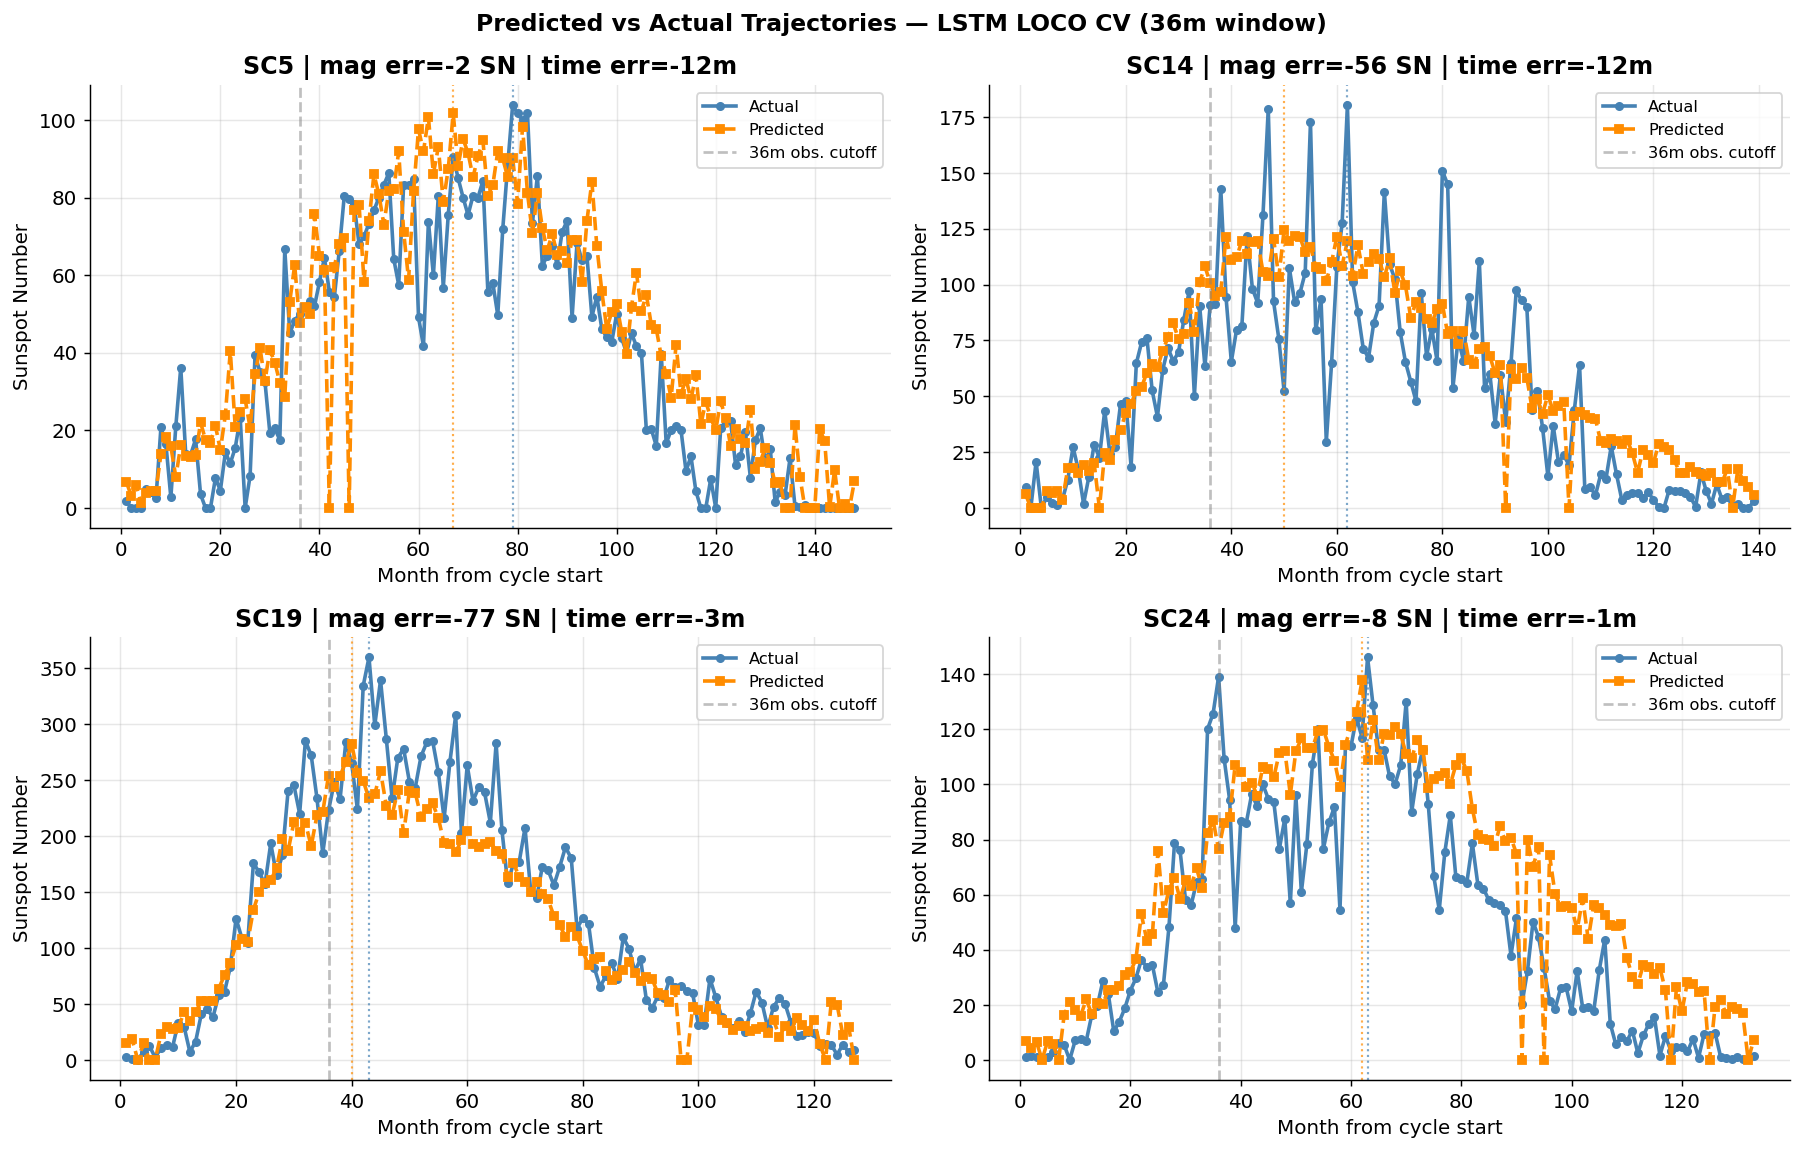

Saved: plots/phase5_trajectories.png


In [13]:
# Plot 1: Example trajectory predictions — best model by Mag_MAE
best_model_name = summary_df.sort_values("Mag_MAE").iloc[0]["Model"]
df_best         = all_loco[best_model_name]

example_cycles = [5, 14, 19, 24]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, cid in zip(axes.flat, example_cycles):
    row    = df_best[df_best["Cycle_ID"] == cid].iloc[0]
    actual = np.array(row["actual_traj"])
    pred   = np.array(row["pred_traj"])
    months = np.arange(1, len(actual) + 1)

    ax.plot(months, actual, "o-",  color="steelblue",  lw=2, ms=4, label="Actual")
    ax.plot(months, pred,   "s--", color="darkorange", lw=2, ms=4, label="Predicted")
    ax.axvline(row["actual_peak_month"], color="steelblue",  lw=1.2, linestyle=":", alpha=0.7)
    ax.axvline(row["pred_peak_month"],   color="darkorange", lw=1.2, linestyle=":", alpha=0.7)
    ax.axvline(WINDOW, color="gray", lw=1.5, linestyle="--", alpha=0.5,
               label=f"{WINDOW}m obs. cutoff")
    ax.set_title(
        f"SC{cid} | mag err={row['mag_error']:+.0f} SN | time err={row['time_error']:+.0f}m",
        fontweight="bold")
    ax.set_xlabel("Month from cycle start")
    ax.set_ylabel("Sunspot Number")
    ax.legend(fontsize=9)

plt.suptitle(
    f"Predicted vs Actual Trajectories — {best_model_name} LOCO CV ({WINDOW}m window)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"plots/phase5_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/phase5_trajectories.png")

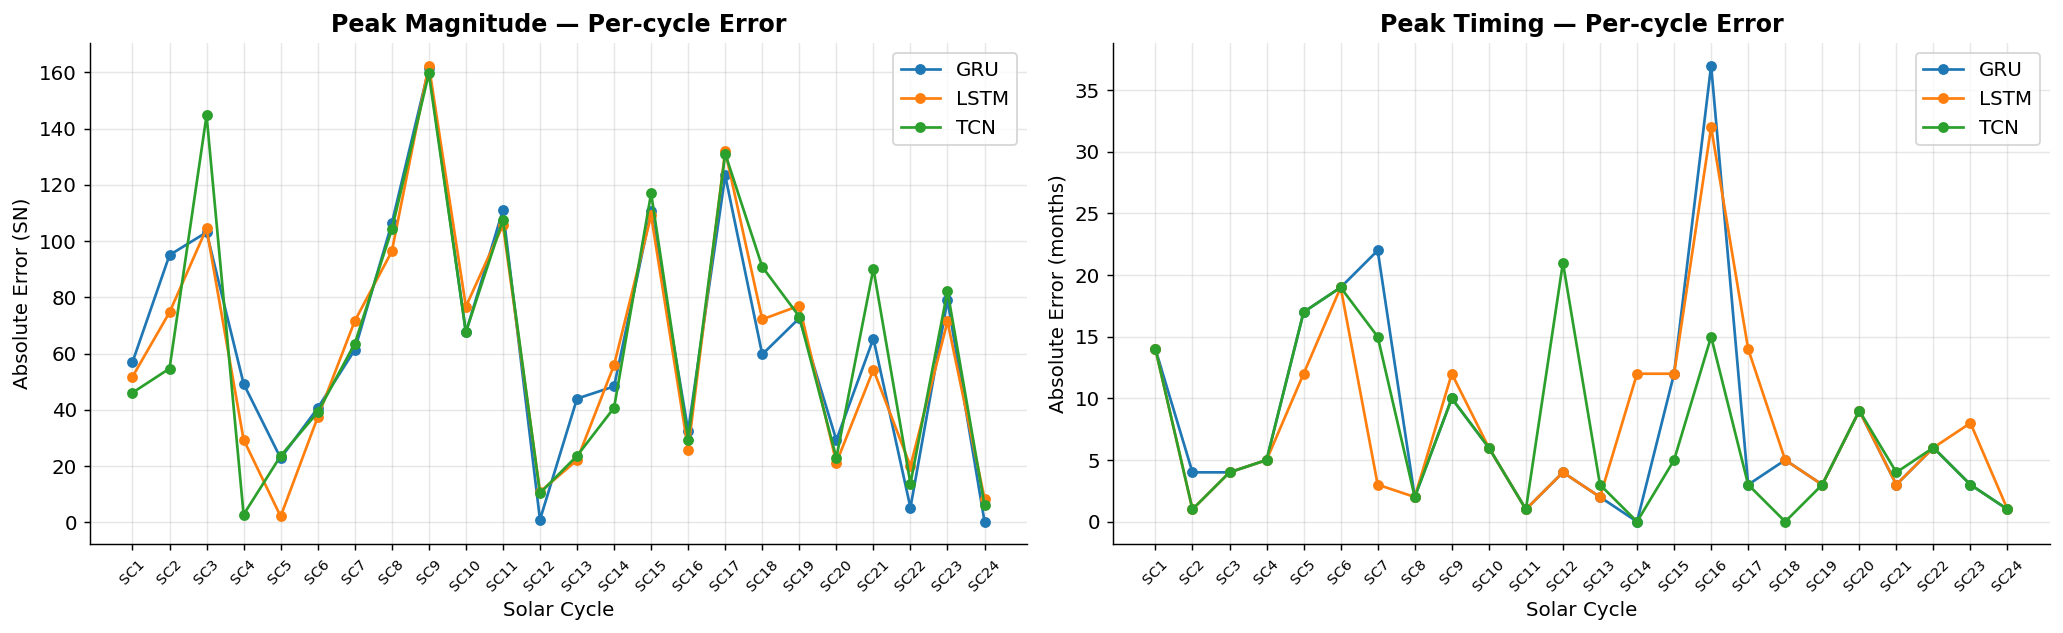

Saved: plots/phase5_error_comparison.png


In [14]:
# Plot 2: Per-cycle magnitude and timing errors across all models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel, title in zip(
    axes,
    ["mag_abs_error", "time_abs_error"],
    ["Absolute Error (SN)", "Absolute Error (months)"],
    ["Peak Magnitude — Per-cycle Error", "Peak Timing — Per-cycle Error"],
):
    for mname, df in all_loco.items():
        ds = df.sort_values("Cycle_ID")
        ax.plot(ds["Cycle_ID"], ds[metric], marker="o", lw=1.5, ms=5, label=mname)
    ax.set_xlabel("Solar Cycle")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(cycle_ids)
    ax.set_xticklabels([f"SC{c}" for c in cycle_ids], rotation=45, fontsize=8)
    ax.legend()

plt.tight_layout()
plt.savefig("plots/phase5_error_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/phase5_error_comparison.png")

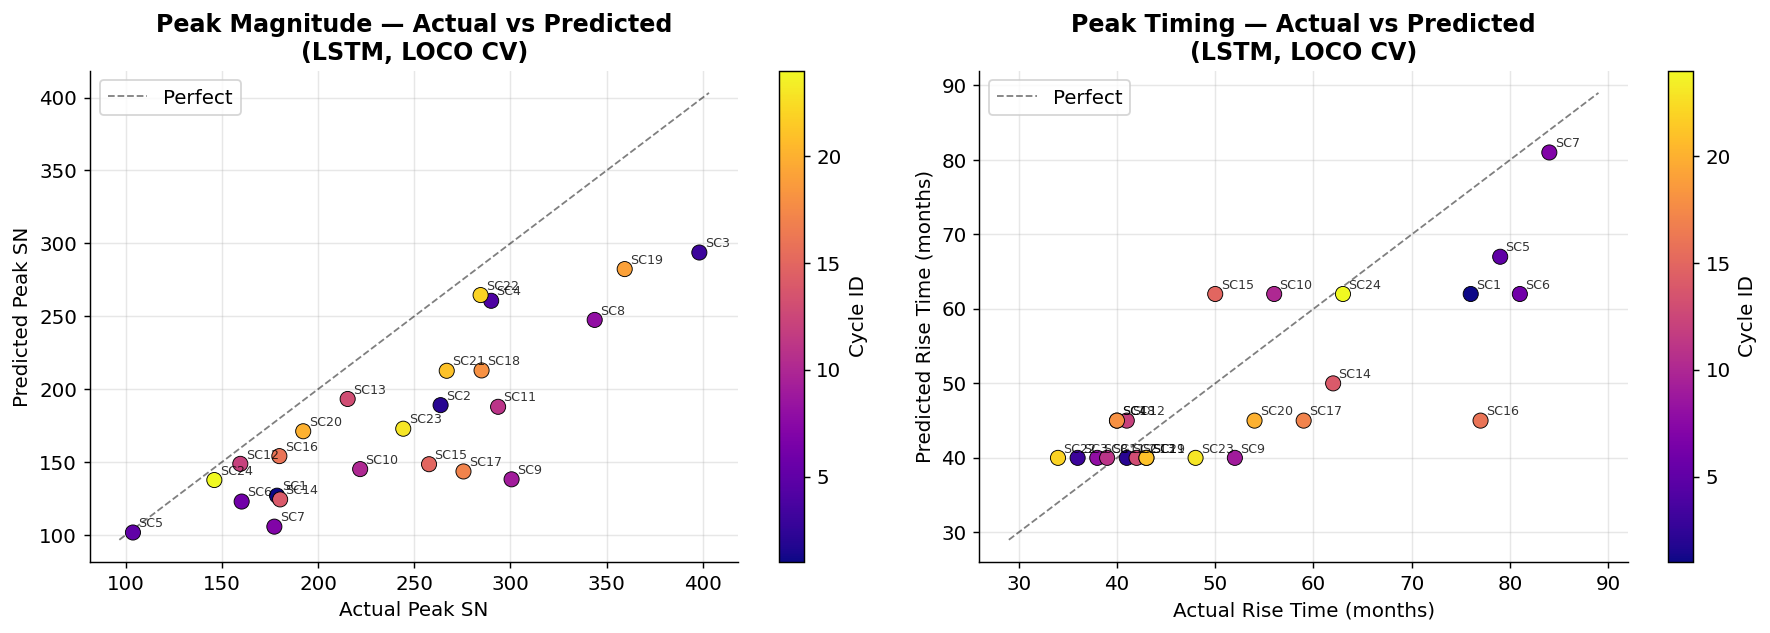

Saved: plots/phase5_pred_vs_actual.png


In [15]:
# Plot 3: Actual vs Predicted peak magnitude — all cycles, best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric_actual, metric_pred, xlabel, ylabel, title) in zip(axes, [
    ("actual_peak_mag",   "pred_peak_mag",
     "Actual Peak SN", "Predicted Peak SN", "Peak Magnitude — Actual vs Predicted"),
    ("actual_peak_month", "pred_peak_month",
     "Actual Rise Time (months)", "Predicted Rise Time (months)", "Peak Timing — Actual vs Predicted"),
]):
    df  = all_loco[best_model_name]
    lo  = min(df[metric_actual].min(), df[metric_pred].min()) - 5
    hi  = max(df[metric_actual].max(), df[metric_pred].max()) + 5
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5, label="Perfect")
    sc = ax.scatter(df[metric_actual], df[metric_pred],
                    c=df["Cycle_ID"], cmap="plasma", s=70,
                    edgecolors="k", linewidths=0.5, zorder=3)
    for _, row in df.iterrows():
        ax.annotate(f"SC{int(row['Cycle_ID'])}",
                    (row[metric_actual], row[metric_pred]),
                    fontsize=7, xytext=(3, 3), textcoords="offset points", alpha=0.8)
    plt.colorbar(sc, ax=ax, label="Cycle ID")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}\n({best_model_name}, LOCO CV)", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.savefig("plots/phase5_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/phase5_pred_vs_actual.png")

## SC25 Trajectory Forecast

In [16]:
# Load SC25 observed data
sc25_full  = pd.read_csv("../data/Cycle_Database.csv",
                          parse_dates=["Start_Date","End_Date","Peak_Date"])
sc25_start = sc25_full[sc25_full["Cycle_ID"] == 25].iloc[0]["Start_Date"]

mask_sc25   = (monthly["Date"] >= sc25_start)
sc25_monthly = monthly.loc[mask_sc25, ["Date","SN_clean"]].copy()
sc25_monthly["SN_clean"] = sc25_monthly["SN_clean"].fillna(0)
sc25_obs    = sc25_monthly["SN_clean"].values

print(f"SC25 start          : {sc25_start.strftime('%Y-%m')}")
print(f"SC25 months observed: {len(sc25_obs)}")
print(f"Observation up to   : {sc25_monthly['Date'].max().strftime('%Y-%m')}")

typical_len = int(np.mean([len(trajectories[c]) for c in cycle_ids]))
print(f"Typical cycle length: {typical_len} months (used for display)")

SC25 start          : 2019-12
SC25 months observed: 78
Observation up to   : 2026-05
Typical cycle length: 133 months (used for display)


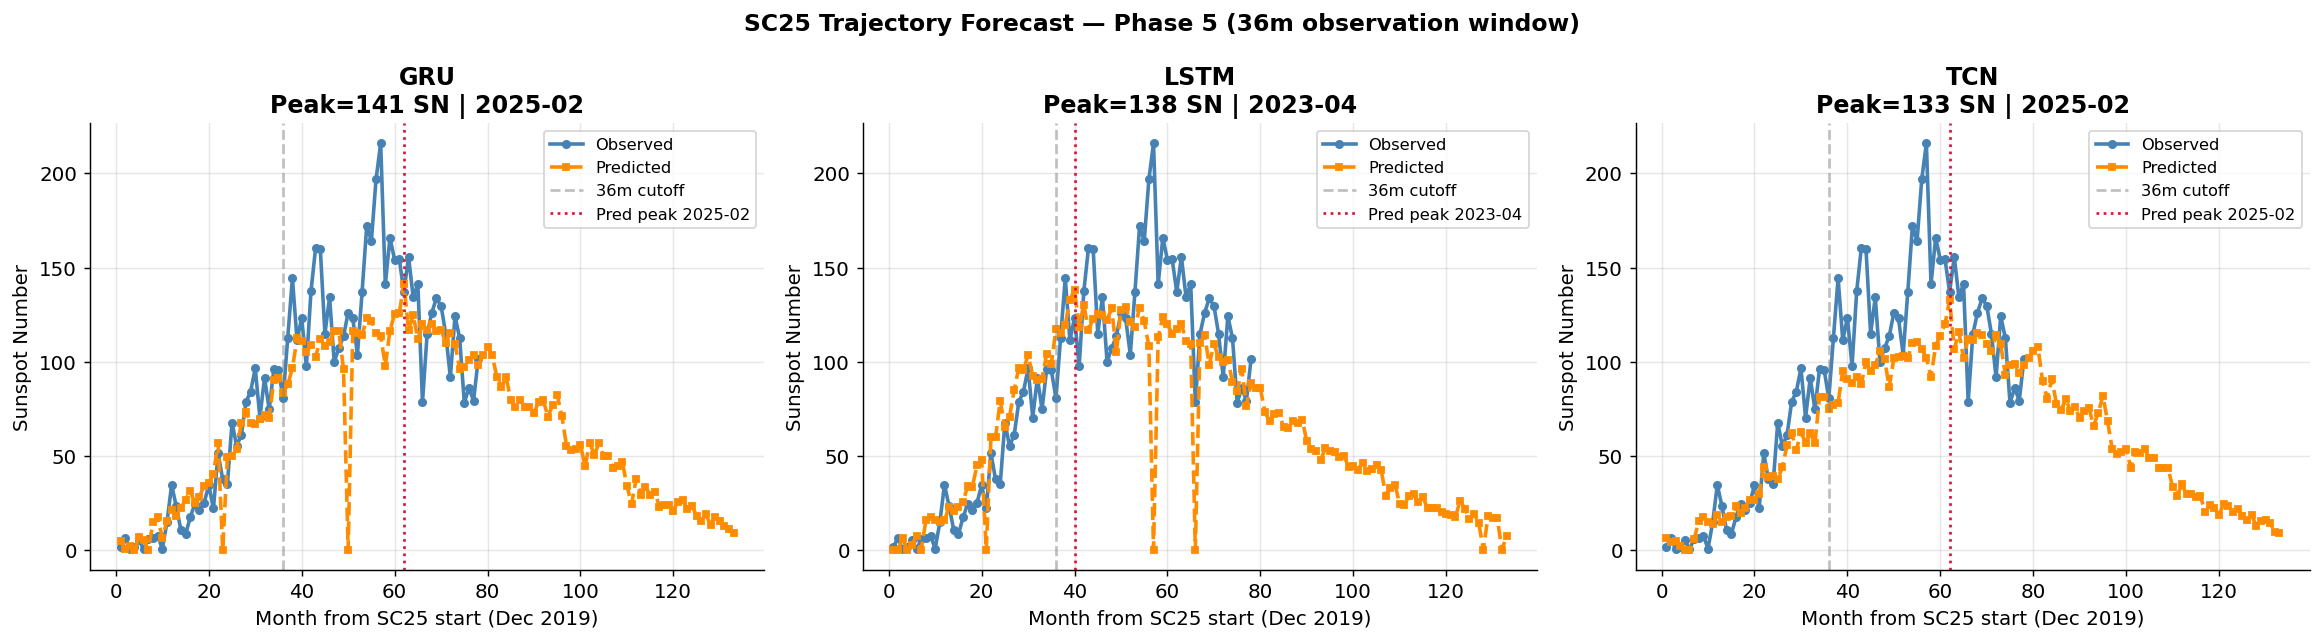


SC25 Trajectory Forecasts:
Model      Peak SN  Peak Month  Calendar Date
GRU          141.3          62m        2025-02
LSTM         138.1          40m        2023-04
TCN          132.9          62m        2025-02


In [17]:
# Train each model on all 24 completed cycles, then forecast SC25
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc25_forecasts = {}

for ax, (mname, mcls) in zip(axes, model_classes.items()):
    X_all = np.array([trajectories[c][:WINDOW] / NORM_FACTOR for c in cycle_ids])
    Y_all = np.array([padded_trajs[c]           / NORM_FACTOR for c in cycle_ids])
    M_all = np.array([traj_masks[c]                            for c in cycle_ids])

    model = train_model(mcls, X_all, Y_all, M_all, output_size=MAX_LEN)

    obs        = np.zeros(WINDOW)
    tlen       = min(len(sc25_obs), WINDOW)
    obs[:tlen] = sc25_obs[:tlen] / NORM_FACTOR

    with torch.no_grad():
        pred_norm = model(torch.FloatTensor(obs).unsqueeze(0).unsqueeze(-1)).numpy()[0]

    pred_traj = pred_norm * NORM_FACTOR
    sc25_forecasts[mname] = pred_traj[:typical_len]

    peak_mag   = float(pred_traj[:typical_len].max())
    peak_month = int(pred_traj[:typical_len].argmax()) + 1
    peak_date  = sc25_start + pd.DateOffset(months=peak_month)

    months_display = np.arange(1, typical_len + 1)
    obs_months     = np.arange(1, len(sc25_obs) + 1)

    ax.plot(obs_months[:typical_len], sc25_obs[:typical_len],
            "o-", color="steelblue", lw=2, ms=4, label="Observed")
    ax.plot(months_display, pred_traj[:typical_len],
            "s--", color="darkorange", lw=2, ms=3, label="Predicted")
    ax.axvline(WINDOW,      color="gray",    lw=1.5, linestyle="--", alpha=0.5,
               label=f"{WINDOW}m cutoff")
    ax.axvline(peak_month,  color="crimson", lw=1.5, linestyle=":",
               label=f"Pred peak {peak_date.strftime('%Y-%m')}")
    ax.set_title(f"{mname}\nPeak={peak_mag:.0f} SN | {peak_date.strftime('%Y-%m')}",
                 fontweight="bold")
    ax.set_xlabel("Month from SC25 start (Dec 2019)")
    ax.set_ylabel("Sunspot Number")
    ax.legend(fontsize=9)

plt.suptitle(f"SC25 Trajectory Forecast — Phase 5 ({WINDOW}m observation window)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/phase5_sc25_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSC25 Trajectory Forecasts:")
print(f"{'Model':<8s}  {'Peak SN':>8s}  {'Peak Month':>10s}  {'Calendar Date':>13s}")
for mname, traj in sc25_forecasts.items():
    pm       = int(traj.argmax()) + 1
    cal_date = sc25_start + pd.DateOffset(months=pm)
    print(f"{mname:<8s}  {traj.max():>8.1f}  {pm:>10d}m  {cal_date.strftime('%Y-%m'):>13s}")

## Save Results

In [18]:
summary_df.to_csv("results/phase5_summary.csv", index=False)
print("Saved: results/phase5_summary.csv")

for mname, df in all_loco.items():
    out = df[["Cycle_ID","actual_peak_mag","pred_peak_mag","mag_error","mag_abs_error",
              "actual_peak_month","pred_peak_month","time_error","time_abs_error"]].copy()
    out.to_csv(f"results/phase5_loco_{mname}.csv", index=False)
    print(f"Saved: results/phase5_loco_{mname}.csv")

sc25_df = pd.DataFrame({
    "month_from_start": np.arange(1, len(next(iter(sc25_forecasts.values()))) + 1),
    **{f"pred_{m}": t for m, t in sc25_forecasts.items()},
})
sc25_df.to_csv("results/phase5_sc25_trajectory.csv", index=False)
print("Saved: results/phase5_sc25_trajectory.csv")
print()
print(summary_df.to_string(index=False))

Saved: results/phase5_summary.csv
Saved: results/phase5_loco_GRU.csv
Saved: results/phase5_loco_LSTM.csv
Saved: results/phase5_loco_TCN.csv
Saved: results/phase5_sc25_trajectory.csv

Model  Mag_MAE  Mag_RMSE  Mag_R2  Time_MAE  Time_RMSE  Time_R2  Elapsed_s
  GRU    64.41     75.95 -0.1144      8.00      11.62   0.4418      130.8
 LSTM    62.18     74.46 -0.0711      7.92      10.59   0.5366       47.5
  TCN    64.35     78.50 -0.1906      6.96       9.39   0.6356       31.8


## Phase 5 Complete

| Output | Description |
|--------|-------------|
| `results/phase5_summary.csv` | LOCO CV metrics for GRU, LSTM, TCN |
| `results/phase5_loco_*.csv` | Per-cycle peak predictions for each model |
| `results/phase5_sc25_trajectory.csv` | SC25 monthly trajectory forecasts |
| `plots/phase5_trajectories.png` | Example cycle trajectory comparisons |
| `plots/phase5_error_comparison.png` | Per-cycle errors across all models |
| `plots/phase5_pred_vs_actual.png` | Scatter: predicted vs actual peak |
| `plots/phase5_sc25_forecast.png` | SC25 trajectory forecast |

**Next:** Phase 6 — Additional datasets (F10.7, Polar Field, Solar Wind, IMF, Kp, Dst)

In [19]:
# Trajectory-level RMSE and MAE for each model
print("Trajectory-level metrics (month-by-month prediction quality):")
print(f"{'Model':<8s}  {'Traj_MAE':>9s}  {'Traj_RMSE':>10s}")
for mname, df in all_loco.items():
    all_errors = []
    for _, row in df.iterrows():
        actual = np.array(row["actual_traj"])
        pred   = np.array(row["pred_traj"])
        all_errors.extend(np.abs(actual - pred).tolist())
    traj_mae  = np.mean(all_errors)
    traj_rmse = np.sqrt(np.mean(np.array(all_errors)**2))
    print(f"{mname:<8s}  {traj_mae:>9.2f}  {traj_rmse:>10.2f}")

Trajectory-level metrics (month-by-month prediction quality):
Model      Traj_MAE   Traj_RMSE
GRU           25.09       34.66
LSTM          24.93       34.75
TCN           25.34       35.74
